In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("blourdhuraju/intel-image-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 243M/243M [00:16<00:00, 15.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1):
['Intel-Image-Classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'test'))}")

Contents of the 'train' directory: ['street', 'sea', 'forest', 'glacier', 'mountain', 'buildings']
Contents of the 'test' directory: ['street', 'sea', 'forest', 'glacier', 'mountain', 'buildings']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/train) ---
Found 12632 images in /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/train. Displaying 6 samples:


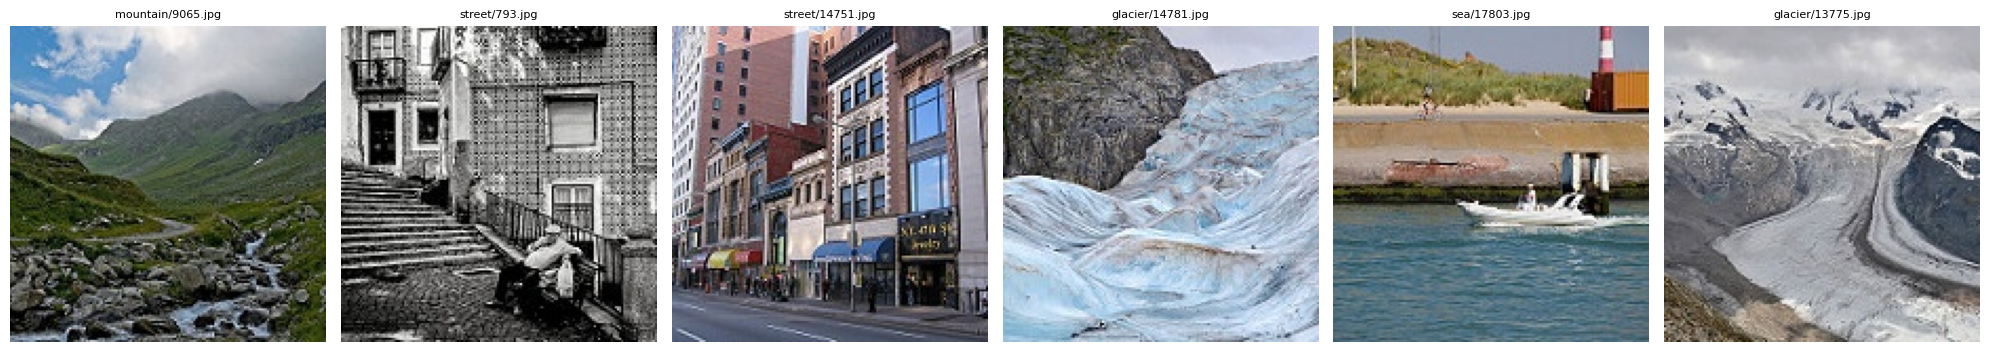


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/test) ---
Found 3000 images in /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/test. Displaying 6 samples:


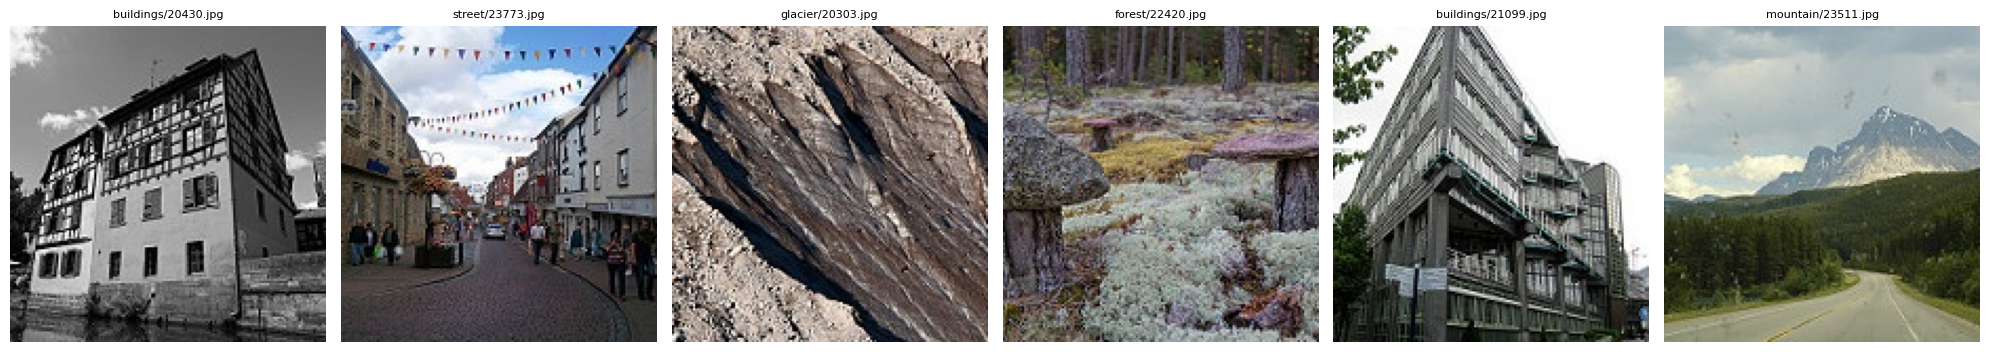

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Intel-Image-Classification' subdirectory
train_path = os.path.join(path, 'Intel-Image-Classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Intel-Image-Classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check for GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found')
else:
    print(f'Found GPU at: {device_name}')

# Check TF version
print(f'TensorFlow version: {tf.__version__}')

Found GPU at: /device:GPU:0
TensorFlow version: 2.20.0


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define constants
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 6

# Prepare Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Build Model using ResNet50 base
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False # Freeze base layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Training
with tf.device('/device:GPU:0'):
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS
    )

Found 10109 images belonging to 6 classes.
Found 2523 images belonging to 6 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 115s 318ms/step - accuracy: 0.2668 - loss: 1.6991 - val_accuracy: 0.3413 - val_loss: 1.5656
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 86s 273ms/step - accuracy: 0.3488 - loss: 1.5141 - val_accuracy: 0.3789 - val_loss: 1.4405
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 86s 274ms/step - accuracy: 0.3849 - loss: 1.4245 - val_accuracy: 0.4158 - val_loss: 1.3627
Epoch 4/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 86s 273ms/step - accuracy: 0.4049 - loss: 1.3814 - val_accuracy: 0.4423 - val_loss: 1.3281
Epoch 5/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 86s 274ms/step - accuracy: 0.4305 - loss: 1.3390 - val_accuracy: 0.4431 - val_loss: 1.3115
Epoch 6/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 86s 270ms/step - accuracy: 0.4248 - loss: 1.3388 - val_accuracy: 0.4665 - val_loss: 1.3031
Epoch 7/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 87s 275ms/step - accuracy: 0.4410 - loss: 1.3143 - val_accuracy: 0.4958 - val_loss: 1.2355
Epoch 8/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 86s 273ms/step - accuracy: 0.4480 - loss: 

In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Evaluate model on test set
results = model.evaluate(test_generator)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

Found 3000 images belonging to 6 classes.
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.5320 - loss: 1.1296
Test Loss: 1.1296
Test Accuracy: 0.5320


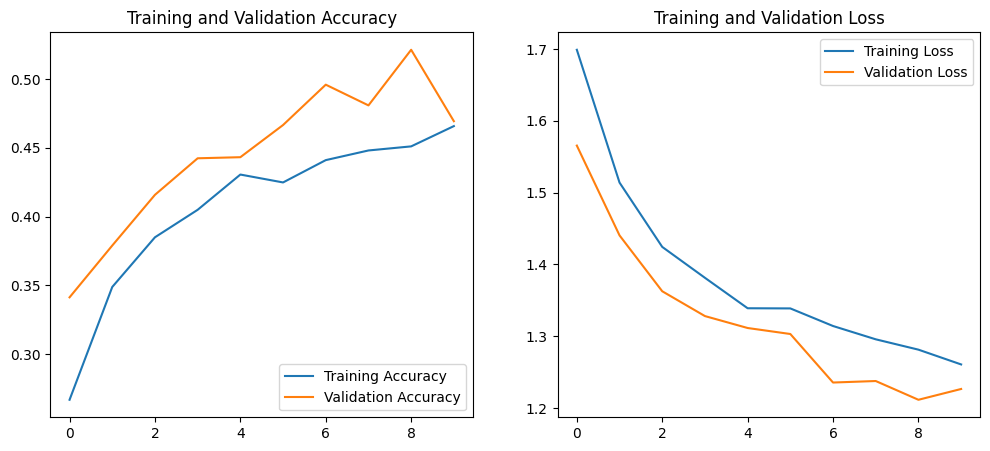

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')

    plt.show()

plot_history(history)